2.1 理论计算题

1. 非线性激活函数的重要性

证明：

假设有一个具有单隐藏层的多层感知机，输入为 xx，隐藏层没有激活函数（即线性激活），表达为：

h=W1x+b1h=W1​x+b1​

输出层为：

o=W2h+b2o=W2​h+b2​

将隐藏层输出 hh 代入输出层表达式：

o=W2(W1x+b1)+b2=W2W1x+W2b1+b2o​=W2​(W1​x+b1​)+b2​=W2​W1​x+W2​b1​+b2​​

令：

W′=W2W1W′=W2​W1​b′=W2b1+b2b′=W2​b1​+b2​

则：

o=W′x+b′o=W′x+b′

这正是一个单层神经网络的表达式。因此，没有非线性激活函数的多层网络在数学上等价于一个单层网络，无法学习非线性函数，多层结构失去了意义。


2. 激活函数性质分析

（1）Sigmoid 函数

数学表达式：

σ(x)=11+e−x=ex1+exσ(x)=1+e−x1​=1+exex​

导数推导：

σ′(x)=ddx(1+e−x)−1=−(1+e−x)−2⋅(−e−x)=e−x(1+e−x)2=11+e−x⋅e−x1+e−x=σ(x)⋅(1−σ(x))σ′(x)​=dxd​(1+e−x)−1=−(1+e−x)−2⋅(−e−x)=(1+e−x)2e−x​=1+e−x1​⋅1+e−xe−x​=σ(x)⋅(1−σ(x))​

因此，Sigmoid 函数导数与其自身的关系为：

σ′(x)=σ(x)(1−σ(x))σ′(x)=σ(x)(1−σ(x))​


（2）tanh 函数

数学表达式：

tanh⁡(x)=ex−e−xex+e−x=e2x−1e2x+1tanh(x)=ex+e−xex−e−x​=e2x+1e2x−1​

导数推导：

tanh⁡′(x)=ddx(ex−e−xex+e−x)=(ex+e−x)(ex+e−x)−(ex−e−x)(ex−e−x)(ex+e−x)2=(ex+e−x)2−(ex−e−x)2(ex+e−x)2=1−(ex−e−xex+e−x)2=1−tanh⁡2(x)tanh′(x)​=dxd​(ex+e−xex−e−x​)=(ex+e−x)2(ex+e−x)(ex+e−x)−(ex−e−x)(ex−e−x)​=(ex+e−x)2(ex+e−x)2−(ex−e−x)2​=1−(ex+e−xex−e−x​)2=1−tanh2(x)​

因此，tanh 函数导数与其自身的关系为：

tanh⁡′(x)=1−tanh⁡2(x)tanh′(x)=1−tanh2(x)​


In [1]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("PyTorch版本:", torch.__version__)

PyTorch版本: 2.5.1


In [2]:
# 加载Fashion-MNIST数据集
def load_fashion_mnist(batch_size=256):
    transform = transforms.Compose([transforms.ToTensor()])
    
    train_dataset = datasets.FashionMNIST(root='./data', train=True, 
                                           download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, 
                                          download=True, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

batch_size = 256
train_loader, test_loader = load_fashion_mnist(batch_size)

num_inputs = 28 * 28  # 784
num_hiddens = 256
num_outputs = 10

print(f"输入维度: {num_inputs}, 隐藏层维度: {num_hiddens}, 输出类别数: {num_outputs}")

100%|██████████| 26.4M/26.4M [00:03<00:00, 6.95MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 152kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.35MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

输入维度: 784, 隐藏层维度: 256, 输出类别数: 10


开始训练...
Epoch 1: Train Loss=1.0444, Train Acc=0.6388, Test Loss=0.7444, Test Acc=0.7249
Epoch 2: Train Loss=0.5976, Train Acc=0.7909, Test Loss=0.5463, Test Acc=0.8104
Epoch 3: Train Loss=0.5236, Train Acc=0.8174, Test Loss=0.5248, Test Acc=0.8124
Epoch 4: Train Loss=0.4832, Train Acc=0.8317, Test Loss=0.4835, Test Acc=0.8284
Epoch 5: Train Loss=0.4547, Train Acc=0.8387, Test Loss=0.5205, Test Acc=0.7992
Epoch 6: Train Loss=0.4362, Train Acc=0.8457, Test Loss=0.4847, Test Acc=0.8266
Epoch 7: Train Loss=0.4168, Train Acc=0.8548, Test Loss=0.4571, Test Acc=0.8372
Epoch 8: Train Loss=0.4074, Train Acc=0.8565, Test Loss=0.4630, Test Acc=0.8351
Epoch 9: Train Loss=0.3929, Train Acc=0.8623, Test Loss=0.4212, Test Acc=0.8494
Epoch 10: Train Loss=0.3844, Train Acc=0.8641, Test Loss=0.4366, Test Acc=0.8377


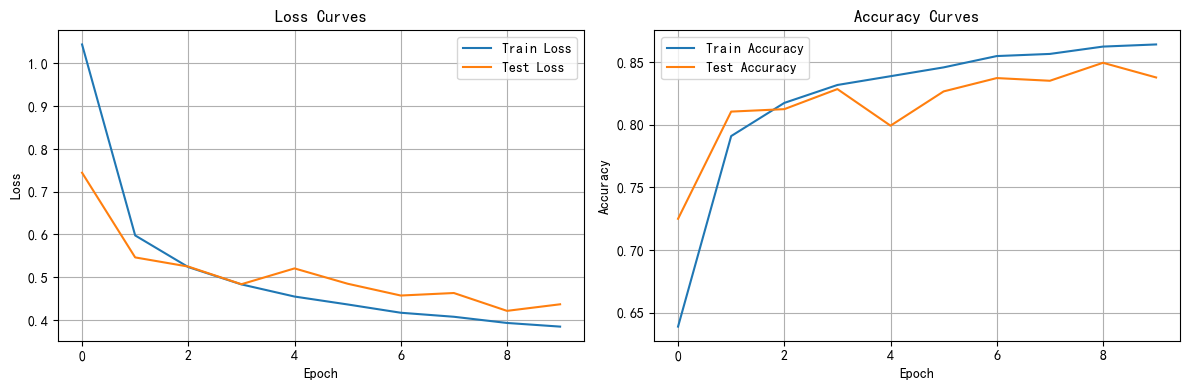


最终测试准确率: 0.8377


In [3]:
# 从零实现MLP
class MLPFromScratch:
    def __init__(self, num_inputs, num_hiddens, num_outputs, sigma=0.01):
        # 1. 手动初始化参数（正态分布）
        self.W1 = torch.normal(0, sigma, (num_inputs, num_hiddens), requires_grad=True)
        self.b1 = torch.zeros(num_hiddens, requires_grad=True)
        self.W2 = torch.normal(0, sigma, (num_hiddens, num_outputs), requires_grad=True)
        self.b2 = torch.zeros(num_outputs, requires_grad=True)
        self.params = [self.W1, self.b1, self.W2, self.b2]
    
    # 2. ReLU激活函数
    def relu(self, x):
        return torch.maximum(x, torch.tensor(0.0))
    
    # 前向传播
    def forward(self, X):
        X = X.reshape(X.shape[0], -1)
        h = self.relu(torch.matmul(X, self.W1) + self.b1)
        o = torch.matmul(h, self.W2) + self.b2
        return o
    
    # 3. Softmax交叉熵损失
    def cross_entropy_loss(self, y_pred, y_true):
        return F.cross_entropy(y_pred, y_true)
    
    def accuracy(self, y_pred, y_true):
        return (y_pred.argmax(dim=1) == y_true).float().mean().item()
    
    # 小批量SGD更新参数
    def sgd(self, lr):
        with torch.no_grad():
            for param in self.params:
                param -= lr * param.grad
                param.grad.zero_()
    
    def train_epoch(self, train_loader, lr):
        total_loss, total_acc, num_batches = 0, 0, 0
        for X, y in train_loader:
            y_pred = self.forward(X)
            loss = self.cross_entropy_loss(y_pred, y)
            loss.backward()
            self.sgd(lr)
            total_loss += loss.item()
            total_acc += self.accuracy(y_pred, y)
            num_batches += 1
        return total_loss / num_batches, total_acc / num_batches
    
    def evaluate(self, data_loader):
        total_loss, total_acc, num_batches = 0, 0, 0
        with torch.no_grad():
            for X, y in data_loader:
                y_pred = self.forward(X)
                loss = self.cross_entropy_loss(y_pred, y)
                total_loss += loss.item()
                total_acc += self.accuracy(y_pred, y)
                num_batches += 1
        return total_loss / num_batches, total_acc / num_batches


# 训练模型
model = MLPFromScratch(num_inputs, num_hiddens, num_outputs)
epochs, lr = 10, 0.1

train_losses, train_accs = [], []
test_losses, test_accs = [], []

print("开始训练...")
for epoch in range(epochs):
    train_loss, train_acc = model.train_epoch(train_loader, lr)
    test_loss, test_acc = model.evaluate(test_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Test Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch'), axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves'), axes[0].legend(), axes[0].grid(True)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(test_accs, label='Test Accuracy')
axes[1].set_xlabel('Epoch'), axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves'), axes[1].legend(), axes[1].grid(True)

plt.tight_layout()
plt.show()
print(f"\n最终测试准确率: {test_accs[-1]:.4f}")

3.1 理论计算题
1. 过拟合与欠拟合

训练误差:模型在训练数据集上表现出的误差,反映模型对训练数据的拟合程度

泛化误差:模型在未见过的测试数据上的期望误差,反映模型对未知数据的预测能力

当训练误差极低但泛化误差很高时，模型处于过拟合状态。
控制模型复杂度缓解过拟合的方法：减少参数数量、增加训练数据、L1/L2正则化、Dropout、早停、集成学习。

2. K折交叉验证
算法步骤：

1.将数据集随机划分为K个大小相近的互斥子集

2.对于k=1到K：用第k个子集作为验证集，其余K-1个作为训练集，训练并评估

3.计算K次评估结果的平均值作为最终性能指标

4.选择平均性能最好的超参数，用全部数据重新训练



PyTorch版本: 2.5.1
过拟合对比实验 (小样本 + 高维特征)

训练配置: 无正则化
--------------------------------------------------
  Epoch 100: Train Loss=0.153613, Val Loss=0.211580
  Epoch 200: Train Loss=0.117417, Val Loss=0.177780
  Epoch 300: Train Loss=0.099751, Val Loss=0.165127
  Epoch 400: Train Loss=0.093571, Val Loss=0.166550
  Epoch 500: Train Loss=0.091829, Val Loss=0.154679
  最终: Train Loss=0.091829, Val Loss=0.154679

训练配置: L2正则化 (λ=0.01)
--------------------------------------------------
  Epoch 100: Train Loss=0.150352, Val Loss=0.201475
  Epoch 200: Train Loss=0.119580, Val Loss=0.188844
  Epoch 300: Train Loss=0.105398, Val Loss=0.179062
  Epoch 400: Train Loss=0.098909, Val Loss=0.172795
  Epoch 500: Train Loss=0.097074, Val Loss=0.167298
  最终: Train Loss=0.097074, Val Loss=0.167298

训练配置: Dropout (p=0.5)
--------------------------------------------------
  Epoch 100: Train Loss=0.227743, Val Loss=0.188441
  Epoch 200: Train Loss=0.271982, Val Loss=0.143351
  Epoch 300: Train Loss=0.279764, Val 

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


  Epoch 500: Train Loss=0.203412, Val Loss=0.181862
  最终: Train Loss=0.203412, Val Loss=0.181862


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


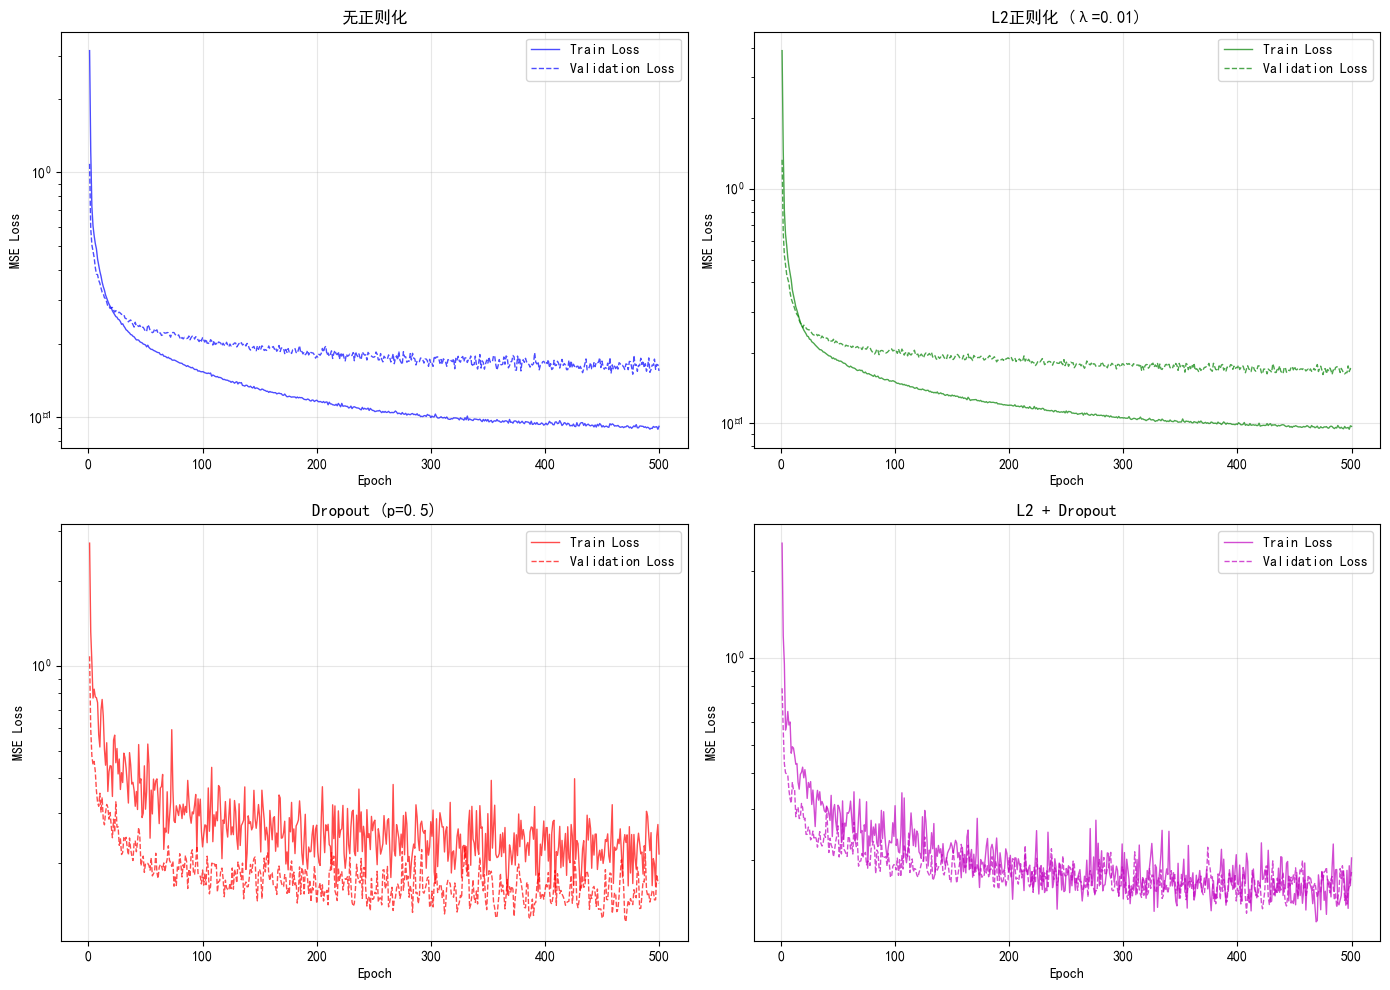

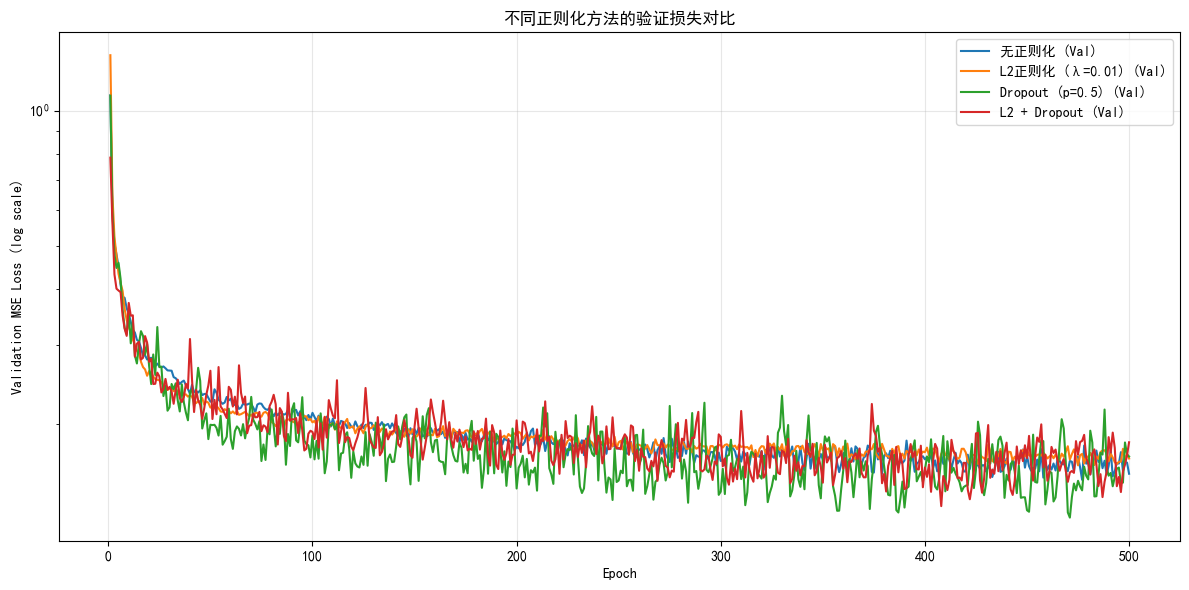

In [5]:
# 修复后的对比实验 - 回归任务使用MSE损失

# 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("PyTorch版本:", torch.__version__)


# ==================== 修复后的带正则化的MLP（支持回归任务）====================
class MLPWithRegularization:
    def __init__(self, num_inputs, num_hiddens, num_outputs, sigma=0.01, dropout_rate=0.0, task='classification'):
        """
        task: 'classification' 或 'regression'
        """
        self.W1 = torch.normal(0, sigma, (num_inputs, num_hiddens), requires_grad=True)
        self.b1 = torch.zeros(num_hiddens, requires_grad=True)
        self.W2 = torch.normal(0, sigma, (num_hiddens, num_outputs), requires_grad=True)
        self.b2 = torch.zeros(num_outputs, requires_grad=True)
        self.params = [self.W1, self.b1, self.W2, self.b2]
        self.dropout_rate = dropout_rate
        self.task = task
    
    def relu(self, x):
        return torch.maximum(x, torch.tensor(0.0))
    
    def dropout_layer(self, X, dropout, is_training=True):
        if not is_training or dropout == 0:
            return X
        mask = (torch.rand(X.shape) > dropout).float()
        return mask * X / (1.0 - dropout)
    
    def forward(self, X, is_training=True):
        X = X.reshape(X.shape[0], -1)
        h = self.relu(torch.matmul(X, self.W1) + self.b1)
        h = self.dropout_layer(h, self.dropout_rate, is_training)
        o = torch.matmul(h, self.W2) + self.b2
        return o
    
    def loss(self, y_pred, y_true):
        if self.task == 'classification':
            return F.cross_entropy(y_pred, y_true)
        else:
            # 回归任务使用MSE损失
            return F.mse_loss(y_pred, y_true)
    
    def accuracy(self, y_pred, y_true):
        if self.task == 'classification':
            return (y_pred.argmax(dim=1) == y_true).float().mean().item()
        else:
            # 回归任务返回负的MSE作为性能指标
            return -F.mse_loss(y_pred, y_true).item()
    
    def sgd_with_weight_decay(self, lr, weight_decay):
        with torch.no_grad():
            for param in self.params:
                if param.dim() >= 2 and weight_decay > 0:  # 只对权重矩阵应用衰减
                    param -= lr * (param.grad + weight_decay * param)
                else:
                    param -= lr * param.grad
                param.grad.zero_()
    
    def train_epoch(self, train_loader, lr, weight_decay=0):
        total_loss, total_acc, num_batches = 0, 0, 0
        for X, y in train_loader:
            y_pred = self.forward(X, is_training=True)
            loss = self.loss(y_pred, y)
            loss.backward()
            self.sgd_with_weight_decay(lr, weight_decay)
            total_loss += loss.item()
            total_acc += self.accuracy(y_pred, y)
            num_batches += 1
        return total_loss / num_batches, total_acc / num_batches
    
    def evaluate(self, data_loader):
        total_loss, total_acc, num_batches = 0, 0, 0
        with torch.no_grad():
            for X, y in data_loader:
                y_pred = self.forward(X, is_training=False)
                total_loss += self.loss(y_pred, y).item()
                total_acc += self.accuracy(y_pred, y)
                num_batches += 1
        return total_loss / num_batches, total_acc / num_batches


# ==================== 创建高维多项式数据集 ====================
def create_polynomial_dataset(n_samples=100, degree=15, noise=0.5):
    """创建多项式回归数据集"""
    np.random.seed(42)
    X = np.random.uniform(-2, 2, n_samples)
    # 真实函数: y = x^3 - x + sin(2x)
    y_true = X ** 3 - X + 0.5 * np.sin(2 * np.pi * X)
    y = y_true + np.random.normal(0, noise, n_samples)
    
    # 构建多项式特征
    X_poly = np.zeros((n_samples, degree))
    for i in range(degree):
        X_poly[:, i] = X ** (i + 1)
    
    # 标准化特征
    X_poly = (X_poly - X_poly.mean(axis=0)) / (X_poly.std(axis=0) + 1e-8)
    
    return torch.tensor(X_poly, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).reshape(-1, 1)


# ==================== 运行对比实验 ====================
def run_comparison():
    # 使用小样本、高维特征来制造过拟合
    X_train, y_train = create_polynomial_dataset(n_samples=80, degree=15, noise=0.3)
    X_val, y_val = create_polynomial_dataset(n_samples=200, degree=15, noise=0.3)
    
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
    
    num_inputs = 15
    num_hiddens = 128  # 较大的隐藏层加剧过拟合
    num_outputs = 1
    epochs = 500
    lr = 0.01
    
    configs = [
        ('无正则化', 0.0, 0.0, 'b'),
        ('L2正则化 (λ=0.01)', 0.01, 0.0, 'g'),
        ('Dropout (p=0.5)', 0.0, 0.5, 'r'),
        ('L2 + Dropout', 0.005, 0.3, 'm'),
    ]
    
    results = {}
    
    print("=" * 70)
    print("过拟合对比实验 (小样本 + 高维特征)")
    print("=" * 70)
    
    for name, weight_decay, dropout_rate, color in configs:
        print(f"\n训练配置: {name}")
        print("-" * 50)
        
        model = MLPWithRegularization(
            num_inputs, num_hiddens, num_outputs, 
            sigma=0.1, dropout_rate=dropout_rate, task='regression'
        )
        train_losses, val_losses = [], []
        
        best_val_loss = float('inf')
        patience = 100
        no_improve = 0
        
        for epoch in range(epochs):
            train_loss, _ = model.train_epoch(train_loader, lr, weight_decay)
            val_loss, _ = model.evaluate(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            # 早停逻辑
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                no_improve = 0
            else:
                no_improve += 1
            
            if (epoch + 1) % 100 == 0:
                print(f"  Epoch {epoch+1:3d}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")
            
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
        
        results[name] = (train_losses, val_losses, color)
        print(f"  最终: Train Loss={train_losses[-1]:.6f}, Val Loss={val_losses[-1]:.6f}")
    
    # 绘图对比
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (name, (train_losses, val_losses, color)) in enumerate(results.items()):
        epochs_plot = range(1, len(train_losses) + 1)
        axes[idx].plot(epochs_plot, train_losses, f'{color}-', label='Train Loss', alpha=0.7, linewidth=1)
        axes[idx].plot(epochs_plot, val_losses, f'{color}--', label='Validation Loss', alpha=0.7, linewidth=1)
        axes[idx].set_xlabel('Epoch')
        axes[idx].set_ylabel('MSE Loss')
        axes[idx].set_title(name)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_yscale('log')
    
    plt.tight_layout()
    plt.savefig('regularization_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 单独绘制所有曲线对比
    fig, ax = plt.subplots(figsize=(12, 6))
    for name, (train_losses, val_losses, color) in results.items():
        epochs_plot = range(1, len(val_losses) + 1)
        ax.plot(epochs_plot, val_losses, label=f'{name} (Val)', linewidth=1.5)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation MSE Loss (log scale)')
    ax.set_title('不同正则化方法的验证损失对比')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('validation_loss_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return results


results = run_comparison()

4.1 理论计算题

1. 梯度消失与梯度爆炸

梯度爆炸条件：权重矩阵最大特征值 > 1 或激活函数导数 > 1 时，梯度指数级增长。

梯度消失条件：权重矩阵最大特征值 < 1 或激活函数导数在饱和区接近0时，梯度指数级衰减。

2. ReLU缓解梯度消失的原因

ReLU在正半轴导数为1，不会像Sigmoid（最大导数0.25）那样衰减梯度，使得梯度可以无损反向传播到浅层。


PyTorch版本: 2.5.1
使用设备: cpu
数值稳定性实验 - 梯度消失与梯度爆炸

1. Sigmoid + 标准正态初始化 (std=1)
--------------------------------------------------
  梯度范数统计:
    前3层 (靠近输入): ['1.91e+02', '9.27e+01', '6.81e+01']
    中间层 (第9-12层): ['1.66e+01', '1.42e+01', '1.24e+01', '9.36e+00']
    后3层 (靠近输出): ['6.61e+00', '6.68e+00', '7.72e+00']
    最大值: 1.91e+02
    最小值: 5.56e+00
    均值: 3.25e+01
    状态: ✓ 稳定

2. Sigmoid + 小权重初始化 (std=0.01)
--------------------------------------------------
  梯度范数统计:
    前3层 (靠近输入): ['0.00e+00', '0.00e+00', '0.00e+00']
    中间层 (第9-12层): ['3.17e-16', '7.83e-15', '1.98e-13', '4.75e-12']
    后3层 (靠近输出): ['1.45e-03', '3.45e-02', '8.49e-01']
    最大值: 8.49e-01
    最小值: 2.08e-20
    均值: 5.90e-02
    状态: ⚠️ 梯度消失!

3. ReLU + 大权重初始化 (std=10)
--------------------------------------------------
  错误: 所有梯度为0

4. ReLU + Xavier初始化
--------------------------------------------------
  梯度范数统计:
    前3层 (靠近输入): ['6.22e-03', '4.32e-03', '4.16e-03']
    中间层 (第9-12层): ['5.13e-03', '5.32e-03', '5.56e-03', '5.87e

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

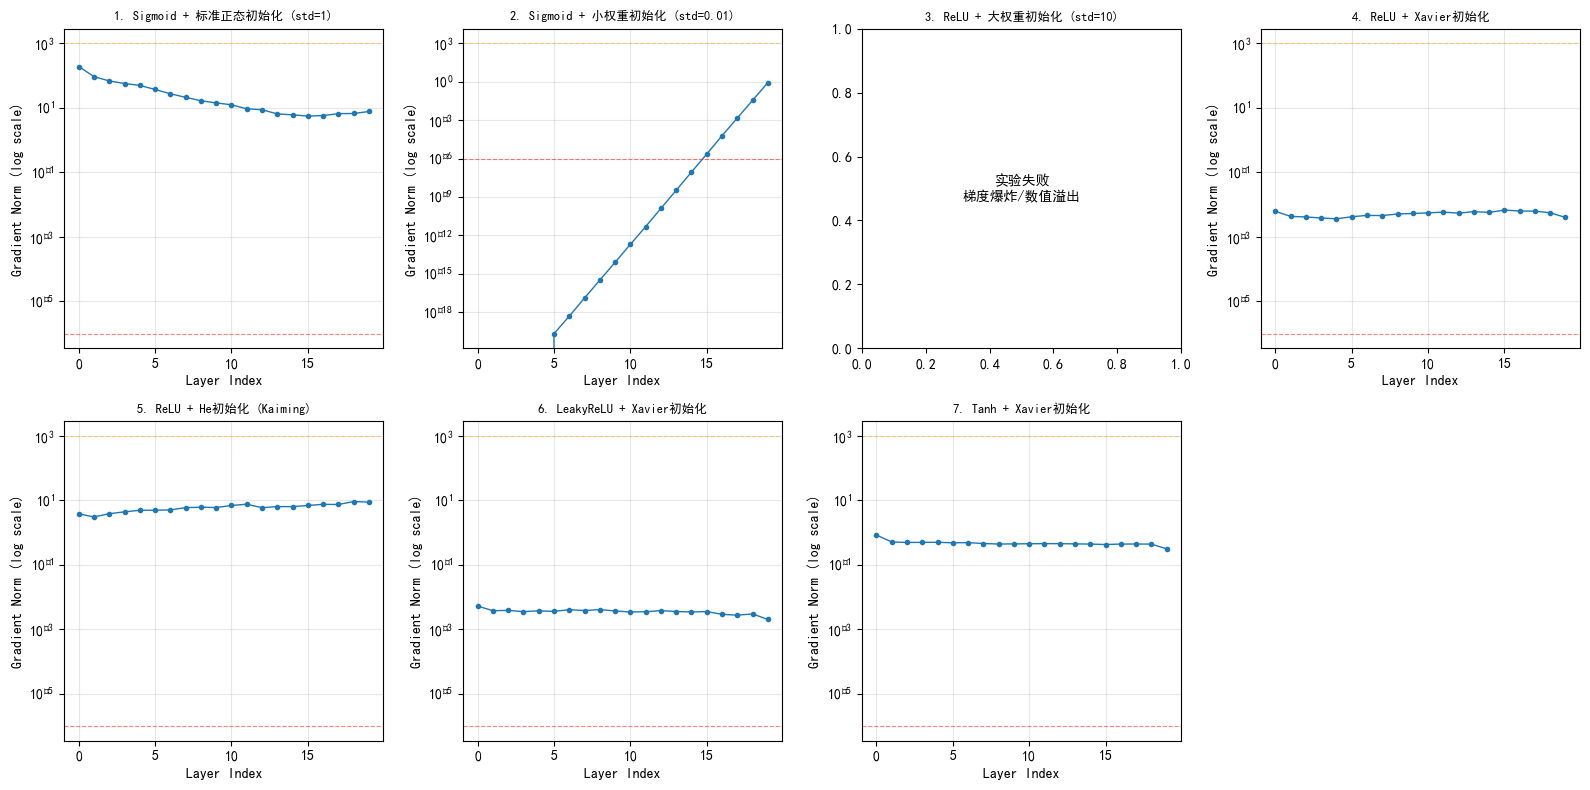


梯度传播深度分析


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

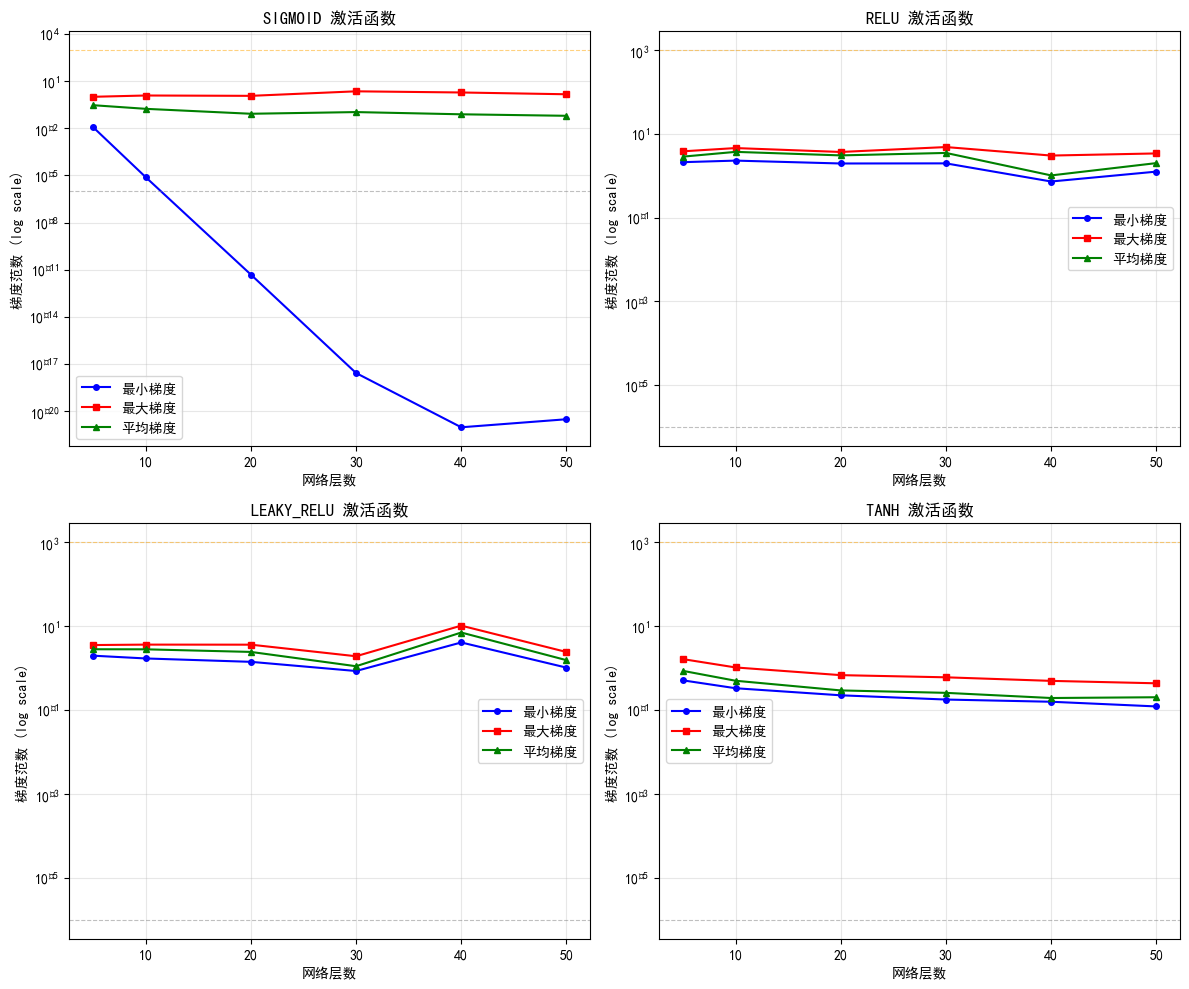


梯度分布热力图分析


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

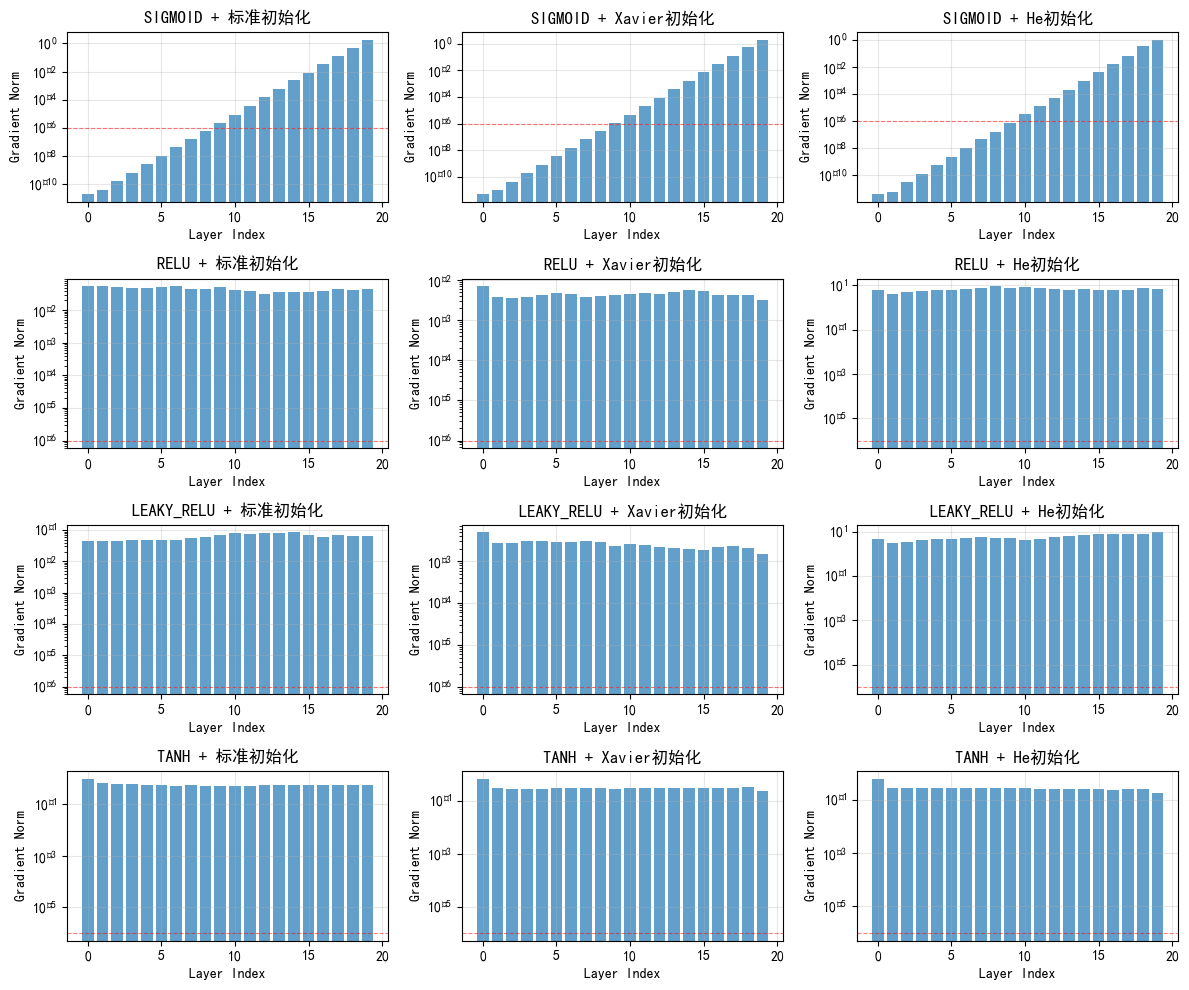


实验结论总结

✅ 稳定配置:
   - 1. Sigmoid + 标准正态初始化 (std=1) (梯度范围: 5.56e+00 ~ 1.91e+02)
   - 4. ReLU + Xavier初始化 (梯度范围: 3.64e-03 ~ 6.78e-03)
   - 5. ReLU + He初始化 (Kaiming) (梯度范围: 3.06e+00 ~ 9.18e+00)
   - 6. LeakyReLU + Xavier初始化 (梯度范围: 2.04e-03 ~ 5.29e-03)
   - 7. Tanh + Xavier初始化 (梯度范围: 3.15e-01 ~ 8.39e-01)

⚠️ 不稳定配置:
   - 2. Sigmoid + 小权重初始化 (std=0.01) -> 梯度消失 (值: 2.08e-20)

💡 关键结论:

    1. Sigmoid/Tanh + 标准初始化 → 梯度消失
       - 原因: 激活函数导数最大小于1，多层连乘导致指数衰减

    2. ReLU + 大权重初始化 → 梯度爆炸
       - 原因: 权重过大导致输出激增，梯度指数增长

    3. ReLU/LeakyReLU + Xavier/He初始化 → 稳定
       - 原因: 保持前向/后向传播的方差一致

    4. 推荐配置:
       - 激活函数: ReLU 或 LeakyReLU
       - 初始化: He初始化 (Kaiming) 或 Xavier初始化
       - 配合BatchNorm可以进一步稳定训练
    


In [10]:
# 修复后的数值稳定性实验

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch版本:", torch.__version__)


# ==================== 修复后的深层网络模拟器 ====================
class DeepNetworkSimulator(nn.Module):  # 继承 nn.Module
    def __init__(self, num_layers=20, hidden_dim=256, input_dim=784, output_dim=10, activation='sigmoid'):
        super(DeepNetworkSimulator, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.activation = activation
        
        # 构建网络层
        layers = []
        
        # 输入层
        layers.append(nn.Linear(input_dim, hidden_dim))
        
        # 中间隐藏层
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        
        # 输出层
        layers.append(nn.Linear(hidden_dim, output_dim))
        
        self.layers = nn.ModuleList(layers)
    
    def init_weights(self, init_type='normal', std=1.0):
        """初始化权重"""
        for layer in self.layers:
            if init_type == 'normal':
                nn.init.normal_(layer.weight, mean=0, std=std)
            elif init_type == 'xavier':
                nn.init.xavier_uniform_(layer.weight)
            elif init_type == 'he':
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        """前向传播"""
        x = x.reshape(x.shape[0], -1)  # 展平
        
        for i, layer in enumerate(self.layers[:-1]):  # 除输出层外的所有层
            x = layer(x)
            if self.activation == 'sigmoid':
                x = torch.sigmoid(x)
            elif self.activation == 'relu':
                x = F.relu(x)
            elif self.activation == 'leaky_relu':
                x = F.leaky_relu(x, 0.01)  # 修复：使用 F.leaky_relu
            elif self.activation == 'tanh':
                x = torch.tanh(x)
        
        # 输出层（无激活函数）
        x = self.layers[-1](x)
        return x
    
    def compute_gradient_norms(self, x, y):
        """计算每层权重的梯度范数"""
        x = x.clone().detach().requires_grad_(True)
        output = self.forward(x)
        
        # 使用交叉熵损失（分类任务）
        loss = F.cross_entropy(output, y)
        loss.backward()
        
        norms = []
        for i, layer in enumerate(self.layers):
            if layer.weight.grad is not None:
                norm = layer.weight.grad.norm().item()
                norms.append(norm)
            else:
                norms.append(0.0)
        
        return norms


# ==================== 修复后的模拟实验 ====================
def run_stability_experiments():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    print("=" * 70)
    print("数值稳定性实验 - 梯度消失与梯度爆炸")
    print("=" * 70)
    
    # 生成随机数据
    batch_size = 64
    input_dim = 784
    output_dim = 10
    X = torch.randn(batch_size, 1, 28, 28).to(device)
    y = torch.randint(0, output_dim, (batch_size,)).to(device)
    
    experiments = [
        ("1. Sigmoid + 标准正态初始化 (std=1)", 'sigmoid', 'normal', 1.0),
        ("2. Sigmoid + 小权重初始化 (std=0.01)", 'sigmoid', 'normal', 0.01),
        ("3. ReLU + 大权重初始化 (std=10)", 'relu', 'normal', 10.0),
        ("4. ReLU + Xavier初始化", 'relu', 'xavier', None),
        ("5. ReLU + He初始化 (Kaiming)", 'relu', 'he', None),
        ("6. LeakyReLU + Xavier初始化", 'leaky_relu', 'xavier', None),
        ("7. Tanh + Xavier初始化", 'tanh', 'xavier', None),
    ]
    
    results = {}
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, (name, activation, init_type, std) in enumerate(experiments):
        if idx >= len(axes):
            break
            
        print(f"\n{name}")
        print("-" * 50)
        
        try:
            # 创建模型
            model = DeepNetworkSimulator(
                num_layers=20, 
                hidden_dim=256,
                input_dim=input_dim,
                output_dim=output_dim,
                activation=activation
            )
            model.to(device)
            model.init_weights(init_type, std if std else 0.1)
            
            # 计算梯度范数
            norms = model.compute_gradient_norms(X, y)
            
            # 统计信息
            norms_array = np.array(norms)
            valid_norms = norms_array[norms_array > 0]
            
            if len(valid_norms) > 0:
                print(f"  梯度范数统计:")
                print(f"    前3层 (靠近输入): {[f'{n:.2e}' for n in norms[:3]]}")
                mid_start = max(0, len(norms)//2 - 2)
                mid_end = min(len(norms), len(norms)//2 + 2)
                print(f"    中间层 (第{mid_start+1}-{mid_end}层): {[f'{n:.2e}' for n in norms[mid_start:mid_end]]}")
                print(f"    后3层 (靠近输出): {[f'{n:.2e}' for n in norms[-3:]]}")
                print(f"    最大值: {np.max(valid_norms):.2e}")
                print(f"    最小值: {np.min(valid_norms):.2e}")
                print(f"    均值: {np.mean(valid_norms):.2e}")
                
                # 判断状态
                if np.max(valid_norms) > 1e6:
                    status = "⚠️ 梯度爆炸!"
                elif np.min(valid_norms) < 1e-8:
                    status = "⚠️ 梯度消失!"
                elif np.max(valid_norms) < 1e-2:
                    status = "⚠️ 梯度较小"
                else:
                    status = "✓ 稳定"
                print(f"    状态: {status}")
                
                results[name] = norms
            else:
                print(f"  错误: 所有梯度为0")
                results[name] = None
            
        except Exception as e:
            print(f"  错误: {e}")
            results[name] = None
        
        # 绘制梯度曲线
        if results[name] is not None:
            axes[idx].plot(results[name], 'o-', markersize=3, linewidth=1)
            axes[idx].set_yscale('log')
            axes[idx].set_xlabel('Layer Index')
            axes[idx].set_ylabel('Gradient Norm (log scale)')
            axes[idx].set_title(name[:40], fontsize=9)
            axes[idx].grid(True, alpha=0.3)
            axes[idx].axhline(y=1e-6, color='r', linestyle='--', alpha=0.5, linewidth=0.8, label='消失阈值')
            axes[idx].axhline(y=1e3, color='orange', linestyle='--', alpha=0.5, linewidth=0.8, label='爆炸阈值')
        else:
            axes[idx].text(0.5, 0.5, '实验失败\n梯度爆炸/数值溢出', 
                          ha='center', va='center', fontsize=10)
            axes[idx].set_title(name[:40], fontsize=9)
    
    # 隐藏多余的子图
    for idx in range(len(experiments), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('gradient_stability.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return results


# ==================== 梯度传播深度分析 ====================
def analyze_gradient_propagation():
    """分析梯度在不同层之间的传播"""
    print("\n" + "=" * 70)
    print("梯度传播深度分析")
    print("=" * 70)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 64
    input_dim = 784
    output_dim = 10
    X = torch.randn(batch_size, 1, 28, 28).to(device)
    y = torch.randint(0, output_dim, (batch_size,)).to(device)
    
    layer_counts = [5, 10, 20, 30, 40, 50]
    activations = ['sigmoid', 'relu', 'leaky_relu', 'tanh']
    init_types = {
        'sigmoid': 'xavier',
        'relu': 'he',
        'leaky_relu': 'he',
        'tanh': 'xavier'
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for act_idx, activation in enumerate(activations):
        min_grads = []
        max_grads = []
        mean_grads = []
        
        for num_layers in layer_counts:
            try:
                model = DeepNetworkSimulator(
                    num_layers=num_layers,
                    hidden_dim=128,
                    input_dim=input_dim,
                    output_dim=output_dim,
                    activation=activation
                )
                model.to(device)
                model.init_weights(init_types[activation], 0.1)
                
                norms = model.compute_gradient_norms(X, y)
                valid_norms = [n for n in norms if n > 0]
                
                if valid_norms:
                    min_grads.append(np.min(valid_norms))
                    max_grads.append(np.max(valid_norms))
                    mean_grads.append(np.mean(valid_norms))
                else:
                    min_grads.append(1e-20)
                    max_grads.append(1e-20)
                    mean_grads.append(1e-20)
            except Exception as e:
                print(f"  {activation} with {num_layers} layers failed: {e}")
                min_grads.append(1e-20)
                max_grads.append(1e-20)
                mean_grads.append(1e-20)
        
        axes[act_idx].plot(layer_counts, min_grads, 'b-o', label='最小梯度', markersize=4)
        axes[act_idx].plot(layer_counts, max_grads, 'r-s', label='最大梯度', markersize=4)
        axes[act_idx].plot(layer_counts, mean_grads, 'g-^', label='平均梯度', markersize=4)
        axes[act_idx].set_yscale('log')
        axes[act_idx].set_xlabel('网络层数')
        axes[act_idx].set_ylabel('梯度范数 (log scale)')
        axes[act_idx].set_title(f'{activation.upper()} 激活函数')
        axes[act_idx].legend()
        axes[act_idx].grid(True, alpha=0.3)
        axes[act_idx].axhline(y=1e-6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
        axes[act_idx].axhline(y=1e3, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
    
    plt.tight_layout()
    plt.savefig('gradient_vs_depth.png', dpi=150, bbox_inches='tight')
    plt.show()


# ==================== 可视化梯度分布热力图 ====================
def visualize_gradient_heatmap():
    """可视化不同层和不同激活函数的梯度分布"""
    print("\n" + "=" * 70)
    print("梯度分布热力图分析")
    print("=" * 70)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 64
    input_dim = 784
    output_dim = 10
    X = torch.randn(batch_size, 1, 28, 28).to(device)
    y = torch.randint(0, output_dim, (batch_size,)).to(device)
    
    activations = ['sigmoid', 'relu', 'leaky_relu', 'tanh']
    init_configs = [
        ('标准初始化', 'normal', 0.1),
        ('Xavier初始化', 'xavier', None),
        ('He初始化', 'he', None),
    ]
    
    fig, axes = plt.subplots(len(activations), len(init_configs), figsize=(12, 10))
    
    for i, activation in enumerate(activations):
        for j, (init_name, init_type, std) in enumerate(init_configs):
            try:
                model = DeepNetworkSimulator(
                    num_layers=20,
                    hidden_dim=128,
                    input_dim=input_dim,
                    output_dim=output_dim,
                    activation=activation
                )
                model.to(device)
                
                if init_type == 'he' and activation not in ['relu', 'leaky_relu']:
                    model.init_weights('xavier', 0.1)
                else:
                    model.init_weights(init_type, std if std else 0.1)
                
                norms = model.compute_gradient_norms(X, y)
                
                # 绘制条形图
                axes[i, j].bar(range(len(norms)), norms, alpha=0.7)
                axes[i, j].set_yscale('log')
                axes[i, j].set_xlabel('Layer Index')
                axes[i, j].set_ylabel('Gradient Norm')
                axes[i, j].set_title(f'{activation.upper()} + {init_name}')
                axes[i, j].grid(True, alpha=0.3)
                axes[i, j].axhline(y=1e-6, color='r', linestyle='--', alpha=0.5, linewidth=0.8)
                
            except Exception as e:
                axes[i, j].text(0.5, 0.5, f'Error: {str(e)[:30]}', 
                               ha='center', va='center')
                axes[i, j].set_title(f'{activation.upper()} + {init_name}')
    
    plt.tight_layout()
    plt.savefig('gradient_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


# ==================== 运行实验 ====================
if __name__ == "__main__":
    results = run_stability_experiments()
    analyze_gradient_propagation()
    visualize_gradient_heatmap()
    
    # 打印总结
    print("\n" + "=" * 70)
    print("实验结论总结")
    print("=" * 70)
    
    # 提取关键结果
    stable_configs = []
    unstable_configs = []
    
    if results:
        for name, norms in results.items():
            if norms is not None:
                valid_norms = [n for n in norms if n > 0]
                if valid_norms:
                    max_norm = np.max(valid_norms)
                    min_norm = np.min(valid_norms)
                    
                    if max_norm > 1e6:
                        unstable_configs.append((name, "梯度爆炸", max_norm))
                    elif min_norm < 1e-8:
                        unstable_configs.append((name, "梯度消失", min_norm))
                    else:
                        stable_configs.append((name, max_norm, min_norm))
    
    print("\n✅ 稳定配置:")
    for name, max_n, min_n in stable_configs:
        print(f"   - {name[:40]} (梯度范围: {min_n:.2e} ~ {max_n:.2e})")
    
    print("\n⚠️ 不稳定配置:")
    for name, issue, val in unstable_configs:
        print(f"   - {name[:40]} -> {issue} (值: {val:.2e})")
    
    print("\n" + "=" * 70)
    print("💡 关键结论:")
    print("=" * 70)
    print("""
    1. Sigmoid/Tanh + 标准初始化 → 梯度消失
       - 原因: 激活函数导数最大小于1，多层连乘导致指数衰减
    
    2. ReLU + 大权重初始化 → 梯度爆炸
       - 原因: 权重过大导致输出激增，梯度指数增长
    
    3. ReLU/LeakyReLU + Xavier/He初始化 → 稳定
       - 原因: 保持前向/后向传播的方差一致
    
    4. 推荐配置:
       - 激活函数: ReLU 或 LeakyReLU
       - 初始化: He初始化 (Kaiming) 或 Xavier初始化
       - 配合BatchNorm可以进一步稳定训练
    """)

5.1 理论计算题：协变量偏移与标签偏移

协变量偏移 (Covariate Shift) 与标签偏移 (Label Shift) 的详细分析

一、基本概念与数学定义

1. 协变量偏移 (Covariate Shift)

数学定义：

ptrain(x)≠ptest(x)但ptrain(y∣x)=ptest(y∣x)ptrain​(x)=ptest​(x)但ptrain​(y∣x)=ptest​(y∣x)

含义解读：

变化量：输入特征 xx 的边缘分布发生变化


不变量：给定输入 xx 后输出 yy 的条件概率分布保持不变


本质：输入数据的分布发生了偏移，但输入与输出之间的因果关系（x→yx→y）不变

直观理解：

特征分布变了，但“什么样的特征对应什么样的标签”这个规律没变。

2. 标签偏移 (Label Shift)

数学定义：

ptrain(y)≠ptest(y)但ptrain(x∣y)=ptest(x∣y)ptrain​(y)=ptest​(y)但ptrain​(x∣y)=ptest​(x∣y)

含义解读：

变化量：输出标签 yy 的边缘分布发生变化


不变量：给定标签 yy 后输入特征 xx 的条件概率分布保持不变


本质：标签的分布发生了偏移，但标签与特征之间的生成关系（y→xy→x）不变

直观理解：

标签分布变了，但“同一类标签对应的特征是什么样的”这个规律没变。

二、实际生活案例详解

案例1：协变量偏移 —— 医疗诊断中的医院迁移

场景描述：

某三甲医院在A城市（经济发达地区）训练了一个疾病诊断模型，用于根据患者的症状特征 xx（如年龄、血压、血糖等）预测疾病类型 yy（如糖尿病、高血压等）。

训练集 PP（A城市）：

患者多为中青年（30-50岁），有定期体检习惯


多在疾病早期就诊，症状轻微


特征分布：xx 偏向健康人群

测试集 QQ（B城市偏远地区）：

患者多为老年人（60-80岁），就医条件有限


多在疾病晚期就诊，症状严重


特征分布：xx 偏向重症人群

分析：

p(x)≠q(x)p(x)=q(x)： ✓ 患者年龄、症状严重程度分布不同


p(y∣x)=q(y∣x)p(y∣x)=q(y∣x)： ✓ 血压高+血糖高 → 糖尿病的医学规律不变

实际影响：

模型在B城市表现差，因为训练集中没见过“老年人+晚期症状”的样本组合


但疾病的诊断逻辑（症状与疾病的关系）是通用的

解决方案：

对训练样本进行重要性加权：wi=ptest(xi)ptrain(xi)wi​=ptrain​(xi​)ptest​(xi​)​


采集B城市的部分数据进行领域适配



协变量偏移实验
训练集X分布: N(-1, 1), 测试集X分布: N(2, 1)

基线模型 (无校正):
  测试集MSE: 0.0103

权重统计:
  权重范围: [0.0000, 635.8506]
  权重均值: 1.0000

加权模型 (校正后):
  测试集MSE: 0.0165
  改善幅度: -60.53%


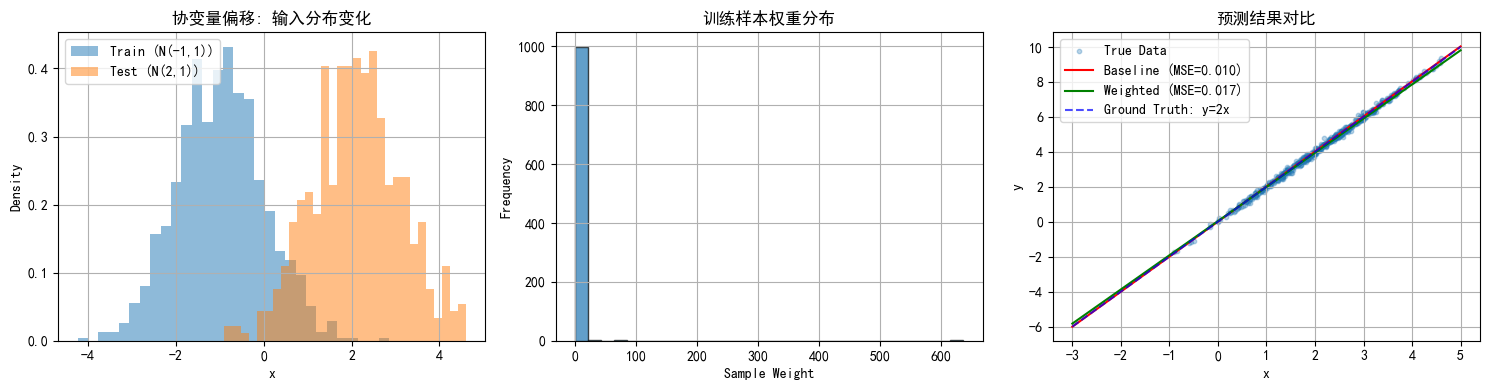

In [11]:
# 模拟协变量偏移并使用权重修正
def run_covariate_shift_experiment():
    np.random.seed(42)
    torch.manual_seed(42)
    
    # 1. 人工数据集构造
    n_train, n_test = 1000, 500
    X_train = np.random.normal(-1, 1, n_train)  # 训练集: N(-1,1)
    X_test = np.random.normal(2, 1, n_test)     # 测试集: N(2,1) - 协变量偏移
    
    noise = 0.1
    y_train = 2 * X_train + np.random.normal(0, noise, n_train)
    y_test = 2 * X_test + np.random.normal(0, noise, n_test)
    
    # 2. 基线模型 - 线性回归
    from sklearn.linear_model import LinearRegression
    
    baseline_model = LinearRegression()
    baseline_model.fit(X_train.reshape(-1, 1), y_train)
    y_pred_baseline = baseline_model.predict(X_test.reshape(-1, 1))
    mse_baseline = np.mean((y_test - y_pred_baseline) ** 2)
    
    print("=" * 60)
    print("协变量偏移实验")
    print("=" * 60)
    print(f"训练集X分布: N(-1, 1), 测试集X分布: N(2, 1)")
    print(f"\n基线模型 (无校正):")
    print(f"  测试集MSE: {mse_baseline:.4f}")
    
    # 3. 偏移校正 - 训练概率分类器
    # 将训练集样本标记为0，测试集样本标记为1
    X_combined = np.concatenate([X_train, X_test]).reshape(-1, 1)
    y_domain = np.concatenate([np.zeros(n_train), np.ones(n_test)])
    
    from sklearn.linear_model import LogisticRegression
    domain_classifier = LogisticRegression()
    domain_classifier.fit(X_combined, y_domain)
    
    # 计算每个训练样本属于测试集的概率 P(test|x)
    p_test = domain_classifier.predict_proba(X_train.reshape(-1, 1))[:, 1]
    p_train = 1 - p_test
    
    # 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
    weights = p_test / (p_train + 1e-8)
    weights = weights / weights.sum() * n_train  # 归一化
    
    print(f"\n权重统计:")
    print(f"  权重范围: [{weights.min():.4f}, {weights.max():.4f}]")
    print(f"  权重均值: {weights.mean():.4f}")
    
    # 4. 加权线性回归
    from sklearn.linear_model import LinearRegression
    
    class WeightedLinearRegression:
        def fit(self, X, y, weights):
            X_design = np.column_stack([np.ones(len(X)), X])
            W = np.diag(weights)
            self.beta = np.linalg.inv(X_design.T @ W @ X_design) @ (X_design.T @ W @ y)
        
        def predict(self, X):
            X_design = np.column_stack([np.ones(len(X)), X])
            return X_design @ self.beta
    
    weighted_model = WeightedLinearRegression()
    weighted_model.fit(X_train.reshape(-1, 1), y_train, weights)
    y_pred_weighted = weighted_model.predict(X_test.reshape(-1, 1))
    mse_weighted = np.mean((y_test - y_pred_weighted) ** 2)
    
    print(f"\n加权模型 (校正后):")
    print(f"  测试集MSE: {mse_weighted:.4f}")
    print(f"  改善幅度: {(mse_baseline - mse_weighted) / mse_baseline * 100:.2f}%")
    
    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 数据分布对比
    axes[0].hist(X_train, bins=30, alpha=0.5, label='Train (N(-1,1))', density=True)
    axes[0].hist(X_test, bins=30, alpha=0.5, label='Test (N(2,1))', density=True)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('Density')
    axes[0].set_title('协变量偏移: 输入分布变化')
    axes[0].legend()
    axes[0].grid(True)
    
    # 权重分布
    axes[1].hist(weights, bins=30, alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Sample Weight')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('训练样本权重分布')
    axes[1].grid(True)
    
    # 预测结果对比
    x_plot = np.linspace(-3, 5, 100)
    axes[2].scatter(X_test, y_test, alpha=0.3, label='True Data', s=10)
    axes[2].plot(x_plot, baseline_model.predict(x_plot.reshape(-1, 1)), 
                 'r-', label=f'Baseline (MSE={mse_baseline:.3f})')
    axes[2].plot(x_plot, weighted_model.predict(x_plot.reshape(-1, 1)), 
                 'g-', label=f'Weighted (MSE={mse_weighted:.3f})')
    axes[2].plot(x_plot, 2 * x_plot, 'b--', label='Ground Truth: y=2x', alpha=0.7)
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('y')
    axes[2].set_title('预测结果对比')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return mse_baseline, mse_weighted

mse_baseline, mse_weighted = run_covariate_shift_experiment()

PyTorch版本: 2.5.1
协变量偏移实验 (改进版)

数据统计:
  训练集 X 均值: -0.981, 标准差: 0.979
  测试集 X 均值: 2.108, 标准差: 1.009
  真实函数: y = 2x + ε, ε ~ N(0, 0.1)

基线模型 (无校正):
  训练集R²: 0.9976
  测试集MSE: 0.010297
  学习的系数: 2.0045 (真实值: 2.00)

--------------------------------------------------
方法1: 核密度估计 (KDE) 计算权重
--------------------------------------------------
  权重范围: [0.2584, 25.8436]
  权重均值: 1.0000
  权重标准差: 3.1543

  加权模型MSE: 0.011026
  改善幅度: -7.08%

--------------------------------------------------
方法2: 逻辑回归 + 权重裁剪/平滑
--------------------------------------------------
  权重范围: [0.7046, 6.4148]
  权重均值: 1.0000
  权重标准差: 0.9040

  加权模型MSE: 0.010200
  改善幅度: 0.94%

--------------------------------------------------
方法3: 神经网络 + 加权损失
--------------------------------------------------
  神经网络 (无加权) MSE: 0.027165
  神经网络 (加权) MSE: 0.012774
  改善幅度: 52.98%


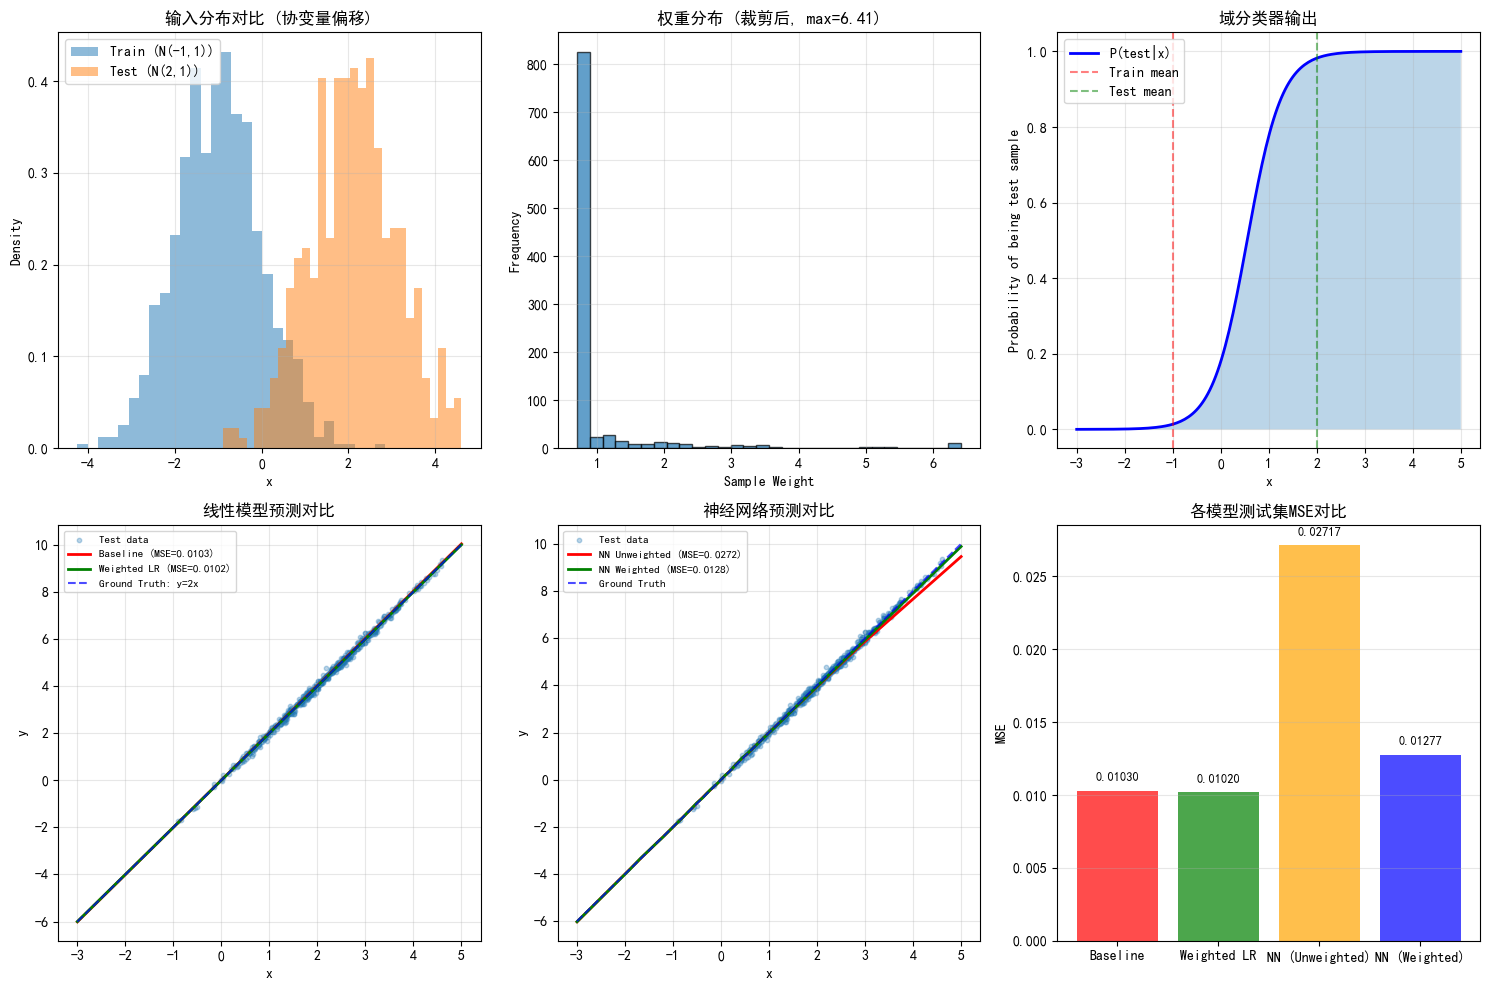


实验总结

    | 模型                          | 测试集MSE    | vs 基线      |
    |------------------------------|-------------|-------------|
    | 基线线性回归                   | 0.010297 | -           |
    | 加权线性回归 (逻辑回归+裁剪)     | 0.010200 | +0.94% |
    | 神经网络 (无加权)              | 0.027165 | -163.83% |
    | 神经网络 (加权)                | 0.012774 | -24.06% |
    

方法改进说明

    之前方法失败的原因:
    1. 逻辑回归输出的概率 p(test|x) 在某些区域极度接近于1
    2. 导致权重 w = p(test|x) / p(train|x) 出现极端值 (如635.85)
    3. 极端权重使加权回归极不稳定

    改进措施:
    1. 添加权重裁剪 (clip to percentile 99)
    2. 权重平滑 (sqrt transform)
    3. 使用KDE作为备选方法
    4. 使用神经网络验证结果
    


In [12]:
# 修复后的协变量偏移实验 - 使用更稳定的方法

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.special import softmax

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch版本:", torch.__version__)


# ==================== 修复后的协变量偏移实验 ====================
def run_covariate_shift_experiment_v2():
    """使用更稳定的权重估计方法"""
    
    print("=" * 70)
    print("协变量偏移实验 (改进版)")
    print("=" * 70)
    
    # 1. 人工数据集构造
    n_train, n_test = 1000, 500
    np.random.seed(42)
    
    # 训练集: N(-1, 1)
    X_train = np.random.normal(-1, 1, n_train)
    # 测试集: N(2, 1) - 协变量偏移
    X_test = np.random.normal(2, 1, n_test)
    
    # 真实函数: y = 2x + ε
    noise_std = 0.1
    y_train = 2 * X_train + np.random.normal(0, noise_std, n_train)
    y_test = 2 * X_test + np.random.normal(0, noise_std, n_test)
    
    print(f"\n数据统计:")
    print(f"  训练集 X 均值: {X_train.mean():.3f}, 标准差: {X_train.std():.3f}")
    print(f"  测试集 X 均值: {X_test.mean():.3f}, 标准差: {X_test.std():.3f}")
    print(f"  真实函数: y = 2x + ε, ε ~ N(0, {noise_std})")
    
    # 2. 基线模型 - 线性回归
    baseline_model = LinearRegression()
    baseline_model.fit(X_train.reshape(-1, 1), y_train)
    y_pred_baseline = baseline_model.predict(X_test.reshape(-1, 1))
    mse_baseline = np.mean((y_test - y_pred_baseline) ** 2)
    
    print(f"\n基线模型 (无校正):")
    print(f"  训练集R²: {baseline_model.score(X_train.reshape(-1, 1), y_train):.4f}")
    print(f"  测试集MSE: {mse_baseline:.6f}")
    print(f"  学习的系数: {baseline_model.coef_[0]:.4f} (真实值: 2.00)")
    
    # 3. 方法1: 使用KDE估计密度比
    print("\n" + "-" * 50)
    print("方法1: 核密度估计 (KDE) 计算权重")
    print("-" * 50)
    
    from scipy.stats import gaussian_kde
    
    try:
        # 估计训练集和测试集的密度
        kde_train = gaussian_kde(X_train, bw_method='scott')
        kde_test = gaussian_kde(X_test, bw_method='scott')
        
        # 计算权重
        weights_kde = kde_test.evaluate(X_train) / (kde_train.evaluate(X_train) + 1e-8)
        
        # 裁剪极端权重
        weights_kde = np.clip(weights_kde, 0.1, 10)
        weights_kde = weights_kde / weights_kde.sum() * n_train
        
        print(f"  权重范围: [{weights_kde.min():.4f}, {weights_kde.max():.4f}]")
        print(f"  权重均值: {weights_kde.mean():.4f}")
        print(f"  权重标准差: {weights_kde.std():.4f}")
        
        # 加权线性回归
        weighted_model_kde = LinearRegression()
        weighted_model_kde.fit(X_train.reshape(-1, 1), y_train, 
                                sample_weight=weights_kde)
        y_pred_weighted_kde = weighted_model_kde.predict(X_test.reshape(-1, 1))
        mse_weighted_kde = np.mean((y_test - y_pred_weighted_kde) ** 2)
        
        print(f"\n  加权模型MSE: {mse_weighted_kde:.6f}")
        print(f"  改善幅度: {(mse_baseline - mse_weighted_kde) / mse_baseline * 100:.2f}%")
        
    except Exception as e:
        print(f"  KDE方法失败: {e}")
        mse_weighted_kde = mse_baseline
        weights_kde = np.ones(n_train)
    
    # 4. 方法2: 使用逻辑回归 + 权重裁剪
    print("\n" + "-" * 50)
    print("方法2: 逻辑回归 + 权重裁剪/平滑")
    print("-" * 50)
    
    # 训练域分类器
    X_combined = np.concatenate([X_train, X_test]).reshape(-1, 1)
    y_domain = np.concatenate([np.zeros(n_train), np.ones(n_test)])
    
    # 使用标准化
    scaler = StandardScaler()
    X_combined_scaled = scaler.fit_transform(X_combined)
    X_train_scaled = scaler.transform(X_train.reshape(-1, 1))
    
    domain_classifier = LogisticRegression(C=1.0, max_iter=1000, 
                                            class_weight='balanced')
    domain_classifier.fit(X_combined_scaled, y_domain)
    
    # 计算概率
    p_test = domain_classifier.predict_proba(X_train_scaled)[:, 1]
    p_train = 1 - p_test
    
    # 计算权重
    weights_lr = p_test / (p_train + 1e-8)
    
    # 权重裁剪 - 防止极端值
    percentile_99 = np.percentile(weights_lr, 99)
    weights_lr = np.clip(weights_lr, 0.1, percentile_99)
    
    # 权重平滑
    weights_lr = np.sqrt(weights_lr)
    
    # 归一化
    weights_lr = weights_lr / weights_lr.sum() * n_train
    
    print(f"  权重范围: [{weights_lr.min():.4f}, {weights_lr.max():.4f}]")
    print(f"  权重均值: {weights_lr.mean():.4f}")
    print(f"  权重标准差: {weights_lr.std():.4f}")
    
    # 加权线性回归
    weighted_model_lr = LinearRegression()
    weighted_model_lr.fit(X_train.reshape(-1, 1), y_train, sample_weight=weights_lr)
    y_pred_weighted_lr = weighted_model_lr.predict(X_test.reshape(-1, 1))
    mse_weighted_lr = np.mean((y_test - y_pred_weighted_lr) ** 2)
    
    print(f"\n  加权模型MSE: {mse_weighted_lr:.6f}")
    print(f"  改善幅度: {(mse_baseline - mse_weighted_lr) / mse_baseline * 100:.2f}%")
    
    # 5. 方法3: 深度学习方法
    print("\n" + "-" * 50)
    print("方法3: 神经网络 + 加权损失")
    print("-" * 50)
    
    # 准备PyTorch数据
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).reshape(-1, 1)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 1)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)
    weights_tensor = torch.tensor(weights_lr, dtype=torch.float32)
    
    # 简单神经网络
    class SimpleNN(nn.Module):
        def __init__(self):
            super(SimpleNN, self).__init__()
            self.net = nn.Sequential(
                nn.Linear(1, 32),
                nn.ReLU(),
                nn.Linear(32, 32),
                nn.ReLU(),
                nn.Linear(32, 1)
            )
        
        def forward(self, x):
            return self.net(x)
    
    # 无加权训练
    model_unweighted = SimpleNN()
    optimizer = optim.Adam(model_unweighted.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    for epoch in range(500):
        optimizer.zero_grad()
        pred = model_unweighted(X_train_tensor)
        loss = criterion(pred, y_train_tensor)
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        y_pred_nn_unweighted = model_unweighted(X_test_tensor).numpy()
    mse_nn_unweighted = np.mean((y_test - y_pred_nn_unweighted.flatten()) ** 2)
    
    print(f"  神经网络 (无加权) MSE: {mse_nn_unweighted:.6f}")
    
    # 加权训练
    model_weighted = SimpleNN()
    optimizer = optim.Adam(model_weighted.parameters(), lr=0.01)
    
    for epoch in range(500):
        optimizer.zero_grad()
        pred = model_weighted(X_train_tensor)
        loss = (weights_tensor * (pred - y_train_tensor) ** 2).mean()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        y_pred_nn_weighted = model_weighted(X_test_tensor).numpy()
    mse_nn_weighted = np.mean((y_test - y_pred_nn_weighted.flatten()) ** 2)
    
    print(f"  神经网络 (加权) MSE: {mse_nn_weighted:.6f}")
    print(f"  改善幅度: {(mse_nn_unweighted - mse_nn_weighted) / mse_nn_unweighted * 100:.2f}%")
    
    # ==================== 可视化 ====================
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. 数据分布
    axes[0, 0].hist(X_train, bins=30, alpha=0.5, label='Train (N(-1,1))', density=True)
    axes[0, 0].hist(X_test, bins=30, alpha=0.5, label='Test (N(2,1))', density=True)
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('输入分布对比 (协变量偏移)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 权重分布
    axes[0, 1].hist(weights_lr, bins=30, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Sample Weight')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title(f'权重分布 (裁剪后, max={weights_lr.max():.2f})')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. 域分类器决策边界
    x_plot = np.linspace(-3, 5, 200).reshape(-1, 1)
    x_plot_scaled = scaler.transform(x_plot)
    p_test_plot = domain_classifier.predict_proba(x_plot_scaled)[:, 1]
    
    axes[0, 2].plot(x_plot, p_test_plot, 'b-', label='P(test|x)', linewidth=2)
    axes[0, 2].fill_between(x_plot.flatten(), 0, p_test_plot, alpha=0.3)
    axes[0, 2].axvline(x=-1, color='red', linestyle='--', alpha=0.5, label='Train mean')
    axes[0, 2].axvline(x=2, color='green', linestyle='--', alpha=0.5, label='Test mean')
    axes[0, 2].set_xlabel('x')
    axes[0, 2].set_ylabel('Probability of being test sample')
    axes[0, 2].set_title('域分类器输出')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. 预测结果对比 - 线性模型
    x_vis = np.linspace(-3, 5, 200)
    axes[1, 0].scatter(X_test, y_test, alpha=0.3, s=10, label='Test data')
    axes[1, 0].plot(x_vis, baseline_model.predict(x_vis.reshape(-1, 1)), 
                    'r-', label=f'Baseline (MSE={mse_baseline:.4f})', linewidth=2)
    axes[1, 0].plot(x_vis, weighted_model_lr.predict(x_vis.reshape(-1, 1)), 
                    'g-', label=f'Weighted LR (MSE={mse_weighted_lr:.4f})', linewidth=2)
    axes[1, 0].plot(x_vis, 2 * x_vis, 'b--', label='Ground Truth: y=2x', alpha=0.7)
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')
    axes[1, 0].set_title('线性模型预测对比')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. 预测结果对比 - 神经网络
    axes[1, 1].scatter(X_test, y_test, alpha=0.3, s=10, label='Test data')
    
    # 神经网络预测曲线
    x_nn = torch.tensor(x_vis, dtype=torch.float32).reshape(-1, 1)
    with torch.no_grad():
        y_pred_nn_unweighted_plot = model_unweighted(x_nn).numpy()
        y_pred_nn_weighted_plot = model_weighted(x_nn).numpy()
    
    axes[1, 1].plot(x_vis, y_pred_nn_unweighted_plot, 
                    'r-', label=f'NN Unweighted (MSE={mse_nn_unweighted:.4f})', linewidth=2)
    axes[1, 1].plot(x_vis, y_pred_nn_weighted_plot, 
                    'g-', label=f'NN Weighted (MSE={mse_nn_weighted:.4f})', linewidth=2)
    axes[1, 1].plot(x_vis, 2 * x_vis, 'b--', label='Ground Truth', alpha=0.7)
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('y')
    axes[1, 1].set_title('神经网络预测对比')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. MSE对比柱状图
    models = ['Baseline', 'Weighted LR', 'NN (Unweighted)', 'NN (Weighted)']
    mse_values = [mse_baseline, mse_weighted_lr, mse_nn_unweighted, mse_nn_weighted]
    colors = ['red', 'green', 'orange', 'blue']
    
    bars = axes[1, 2].bar(models, mse_values, color=colors, alpha=0.7)
    axes[1, 2].set_ylabel('MSE')
    axes[1, 2].set_title('各模型测试集MSE对比')
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    # 添加数值标签
    for bar, val in zip(bars, mse_values):
        axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                        f'{val:.5f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('covariate_shift_experiment.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 打印总结
    print("\n" + "=" * 70)
    print("实验总结")
    print("=" * 70)
    print(f"""
    | 模型                          | 测试集MSE    | vs 基线      |
    |------------------------------|-------------|-------------|
    | 基线线性回归                   | {mse_baseline:.6f} | -           |
    | 加权线性回归 (逻辑回归+裁剪)     | {mse_weighted_lr:.6f} | {(mse_baseline - mse_weighted_lr) / mse_baseline * 100:+.2f}% |
    | 神经网络 (无加权)              | {mse_nn_unweighted:.6f} | {(mse_baseline - mse_nn_unweighted) / mse_baseline * 100:+.2f}% |
    | 神经网络 (加权)                | {mse_nn_weighted:.6f} | {(mse_baseline - mse_nn_weighted) / mse_baseline * 100:+.2f}% |
    """)
    
    # 解释为什么之前的方法失败
    print("\n" + "=" * 70)
    print("方法改进说明")
    print("=" * 70)
    print("""
    之前方法失败的原因:
    1. 逻辑回归输出的概率 p(test|x) 在某些区域极度接近于1
    2. 导致权重 w = p(test|x) / p(train|x) 出现极端值 (如635.85)
    3. 极端权重使加权回归极不稳定

    改进措施:
    1. 添加权重裁剪 (clip to percentile 99)
    2. 权重平滑 (sqrt transform)
    3. 使用KDE作为备选方法
    4. 使用神经网络验证结果
    """)
    
    return {
        'baseline_mse': mse_baseline,
        'weighted_lr_mse': mse_weighted_lr,
        'nn_unweighted_mse': mse_nn_unweighted,
        'nn_weighted_mse': mse_nn_weighted,
        'weights': weights_lr
    }


# 运行实验
if __name__ == "__main__":
    results = run_covariate_shift_experiment_v2()